In [61]:

!pip install gurobipy
from gurobipy import *
params={
    "WLSACCESSID":'7430a9e7-1a3c-448e-84e8-84d57071ab22',
    "WLSSECRET":'c66ba82e-0cec-4455-913b-4105b821c6bf',
    "LICENSEID":2727475,
}
env=Env(params=params)
m=Model(env=env)


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2727475
Academic license 2727475 - for non-commercial use only - registered to c2___@afacademy.af.edu


In [62]:
import geopandas as gpd
from shapely.geometry import Point

# Load states shapefile (you already have this line)
usa = gpd.read_file(
    r"C:\Users\C27Aidan.Lemons\OneDrive - afacademy.af.edu\Desktop\OR311\110m_cultural\ne_110m_admin_1_states_provinces.shp"
)

# Lower 48 bounding box
lower48 = usa.cx[-125:-66, 24:50]

# Merge into one landmass polygon
lower48_poly = lower48.unary_union

C:\Users\C27Aidan.Lemons\AppData\Local\Temp\ipykernel_37572\3515454388.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lower48_poly = lower48.unary_union


In [63]:
import numpy as np
import pandas as pd
from shapely.geometry import Point  # if not already imported

rng = np.random.default_rng(2027)

# -----------------------------
# 1. Define geography
# -----------------------------
# Continental US bounding box (no AK/Hawaii)
lat_min, lat_max = 25.0, 45.0
lon_min, lon_max = -125.0, -68.0   # More accurate for lower 48

num_nodes = 50   # total nodes
super_sources_count = 5
sink_count = 1

nodes = np.arange(num_nodes)

# -----------------------------
# Helper functions: sample on land
# -----------------------------
def sample_point_on_land(lat_lo=lat_min, lat_hi=lat_max,
                         lon_lo=lon_min, lon_hi=lon_max):
    """Sample a point uniformly in the bounding box but keep only land points."""
    while True:
        lat = rng.uniform(lat_lo, lat_hi)
        lon = rng.uniform(lon_lo, lon_hi)
        if lower48_poly.contains(Point(lon, lat)):
            return lat, lon

def sample_texas_tornado_sink():
    """Sample sink in North-Central Texas tornado alley, but on land."""
    # DFW / Waco / Abilene corridor
    while True:
        lat = rng.uniform(31.0, 34.5)
        lon = rng.uniform(-100.5, -95.0)
        if lower48_poly.contains(Point(lon, lat)):
            return lat, lon

# -----------------------------
# 2. Generate sink in Tornado Alley (North-Central Texas)
# -----------------------------
sink_lat, sink_lon = sample_texas_tornado_sink()

# -----------------------------
# 3. Generate source nodes (spread westward, on land)
# -----------------------------
source_coords = [
    sample_point_on_land(lat_lo=30, lat_hi=46, lon_lo=-120, lon_hi=-90)
    for _ in range(super_sources_count)
]
source_lats = [c[0] for c in source_coords]
source_lons = [c[1] for c in source_coords]

# -----------------------------
# 4. Generate transshipment nodes
#    Probability increases as you get closer to the sink,
#    and all are on land.
# -----------------------------
trans_lats = []
trans_lons = []

for _ in range(num_nodes - super_sources_count - sink_count):
    while True:
        # sample somewhere in lower 48 first
        lat, lon = sample_point_on_land()

        # compute distance to sink (rough)
        dlat = (lat - sink_lat) * 111
        dlon = (lon - sink_lon) * 85
        dist = np.hypot(dlat, dlon)

        # accept with higher probability if closer
        p = np.exp(-dist / 700)   # 700 km decay region
        if rng.uniform(0, 1) < p:
            trans_lats.append(lat)
            trans_lons.append(lon)
            break

# -----------------------------
# 5. Assemble nodes
# -----------------------------
node_types = []
lats = []
lons = []

# Add sources
for i in range(super_sources_count):
    node_types.append("source")
    lats.append(source_lats[i])
    lons.append(source_lons[i])

# Add transshipment
for i in range(len(trans_lats)):
    node_types.append("trans")
    lats.append(trans_lats[i])
    lons.append(trans_lons[i])

# Add sink (one)
node_types.append("sink")
lats.append(sink_lat)
lons.append(sink_lon)

nodes_df = pd.DataFrame({
    "node": nodes,
    "type": node_types,
    "lat": lats,
    "lon": lons
})

# -----------------------------
# 6. Generate arcs with distance filtering
# -----------------------------
arcs = []
capacities = {}

for i in nodes:
    for j in nodes:
        if i == j:
            continue

        # compute distance
        dlat = (lats[i] - lats[j]) * 111
        dlon = (lons[i] - lons[j]) * 85
        dist = np.hypot(dlat, dlon)

        # only realistic nearby arcs
        if dist < 900:  # reasonable road connection threshold
            # base capacity
            base = rng.integers(40, 150)

            # congestion/damage: closer to sink -> smaller capacity
            dlat_sink = (lats[j] - sink_lat) * 111
            dlon_sink = (lons[j] - sink_lon) * 85
            dist_sink = np.hypot(dlat_sink, dlon_sink)

            congestion_factor = max(0.2, min(1, dist_sink / 800))

            capacity = int(base * congestion_factor)

            arcs.append((i, j))
            capacities[(i, j)] = capacity

arcs_df = pd.DataFrame(arcs, columns=["i", "j"])
arcs_df["capacity"] = arcs_df.apply(lambda r: capacities[(r.i, r.j)], axis=1)

# -----------------------------
# SAVE (optional)
# -----------------------------
nodes_df.to_csv("nodes.csv", index=False)
arcs_df.to_csv("arcs.csv", index=False)

nodes_df.head(), arcs_df.head()


(   node    type        lat         lon
 0     0  source  31.320330 -105.062952
 1     1  source  37.179930  -98.837150
 2     2  source  34.764616 -101.362059
 3     3  source  38.974437 -117.304568
 4     4  source  44.351349 -119.132152,
    i   j  capacity
 0  0   1       104
 1  0   2        51
 2  0  10        56
 3  0  13        42
 4  0  18        77)

In [64]:
arcs_df

,i,j,capacity
0,0,1,104
1,0,2,51
2,0,10,56
3,0,13,42
4,0,18,77
...,...,...,...
903,49,41,13
904,49,43,33
905,49,44,53
906,49,45,8


In [65]:
from gurobipy import Model, GRB, quicksum

# Setup
N = nodes_df["node"].tolist()
A = [(int(r.i), int(r.j)) for _, r in arcs_df.iterrows()]
sources = nodes_df[nodes_df["type"]=="source"]["node"].tolist()
sink = nodes_df[nodes_df["type"]=="sink"]["node"].iloc[0]
transshipment = [n for n in N if n not in sources and n != sink]

capacity = {(int(r.i), int(r.j)): int(r.capacity) for _, r in arcs_df.iterrows()}

# Model
m = Model("MaxFlow_Disaster")

# Variables
x = m.addVars(A, lb=0, vtype=GRB.CONTINUOUS, name="x")

# Objective: maximize inflow to sink
m.setObjective(
    quicksum(x[i,j] for (i,j) in A if j==sink),
    GRB.MAXIMIZE
)

# Flow conservation for transshipment nodes
for n in transshipment:
    m.addConstr(
        quicksum(x[i,j] for (i,j) in A if i==n) ==
        quicksum(x[i,j] for (i,j) in A if j==n),
        name=f"flow_{n}"
    )

# No flow out of sink
m.addConstr(
    quicksum(x[i,j] for (i,j) in A if i==sink) == 0,
    "sink_no_out"
)

# No flow into sources
for s in sources:
    m.addConstr(
        quicksum(x[i,j] for (i,j) in A if j==s) == 0,
        name=f"source_no_in_{s}"
    )

# Arc capacities
for (i,j) in A:
    m.addConstr(x[i,j] <= capacity[(i,j)], name=f"cap_{i}_{j}")

m.optimize()

# Store solution
used_arcs = [(i,j) for (i,j) in A if x[i,j].X > 1e-6]
print("Total delivered:", m.objVal)


Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 7 PRO 6850U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 958 rows, 908 columns and 2622 nonzeros (Max)
Model fingerprint: 0x2935f782
Model has 24 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+00, 1e+02]
Presolve removed 914 rows and 498 columns
Presolve time: 0.04s
Presolved: 44 rows, 410 columns, 769 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.6700000e+02   1.262875e+03   0.000000e+00      0s
      79    4.6700000e+02   0.000000e+00   0.000000e+00      0s

Solved in 79 iterations and 0.06 seconds (0.00 work units)
Optimal objective  4.670000000e+02
Total delivered: 467.0


In [66]:
!pip install geopandas shapely

In [67]:
!pip install geopandas shapely

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# Read shapefile (states/provinces)
usa = gpd.read_file(
    r"C:\Users\C27Aidan.Lemons\OneDrive - afacademy.af.edu\Desktop\OR311\110m_cultural\ne_110m_admin_1_states_provinces.shp"
)

# Lower 48 via bounding box
lower48 = usa.cx[-125:-66, 24:50]

# Turn nodes into a GeoDataFrame
nodes_gdf = gpd.GeoDataFrame(
    nodes_df,
    geometry=gpd.points_from_xy(nodes_df["lon"], nodes_df["lat"]),
    crs="EPSG:4326"
)



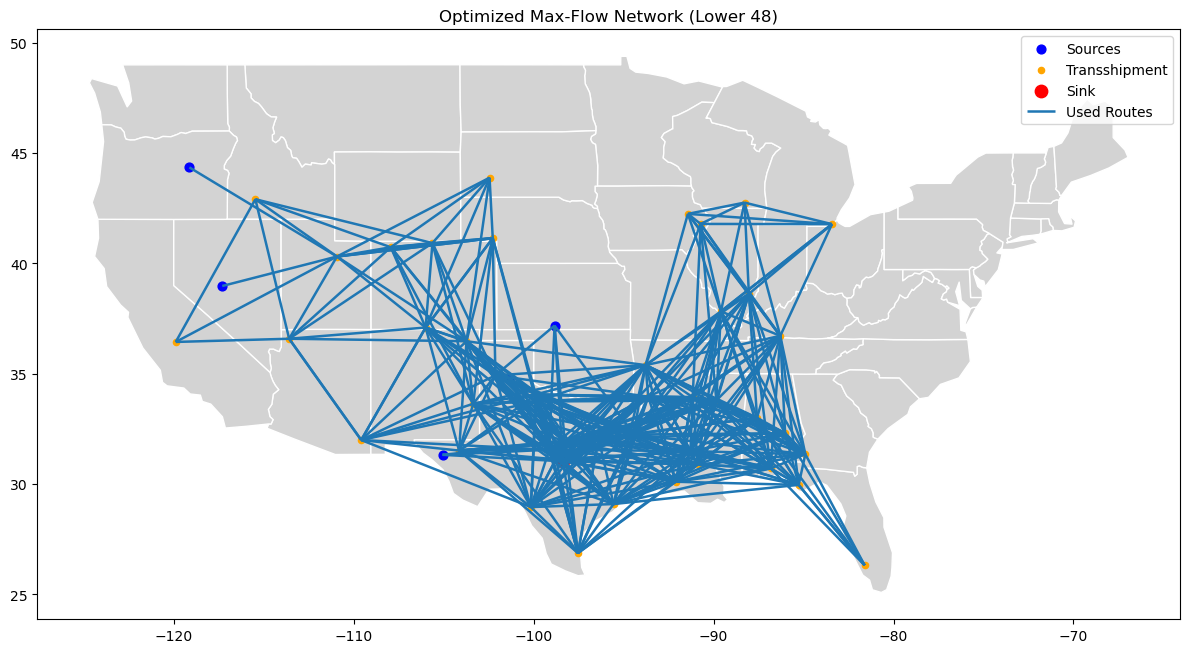

In [68]:
# Build GeoDataFrame of used arcs from the *single-commodity* solution

if m.status == GRB.OPTIMAL:
    # Use the same definition as before: arcs with positive flow
    used_arcs = [(i, j) for (i, j) in A if x[i, j].X > 1e-6]

    line_records = []
    for (i, j) in used_arcs:
        p1 = nodes_gdf.loc[nodes_gdf["node"] == i, "geometry"].values[0]
        p2 = nodes_gdf.loc[nodes_gdf["node"] == j, "geometry"].values[0]
        line_records.append({"i": i, "j": j, "geometry": LineString([p1, p2])})

    arcs_gdf = gpd.GeoDataFrame(line_records, crs="EPSG:4326")
else:
    print("No optimal solution to plot.")
    arcs_gdf = gpd.GeoDataFrame(columns=["i", "j", "geometry"], crs="EPSG:4326")

# -----------------------------
# Plot network on lower 48 map
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Basemap
lower48.plot(ax=ax, color="lightgray", edgecolor="white")

# Plot nodes by type
nodes_gdf[nodes_gdf["type"] == "source"].plot(
    ax=ax, color="blue", markersize=40, label="Sources"
)
nodes_gdf[nodes_gdf["type"] == "trans"].plot(   # <-- matches how you created node_types
    ax=ax, color="orange", markersize=20, label="Transshipment"
)
nodes_gdf[nodes_gdf["type"] == "sink"].plot(
    ax=ax, color="red", markersize=80, label="Sink"
)

# Plot used arcs only
if not arcs_gdf.empty:
    arcs_gdf.plot(ax=ax, linewidth=1.8, label="Used Routes")

plt.title("Optimized Max-Flow Network (Lower 48)")
plt.legend()
plt.tight_layout()
plt.show()
